In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

# Set plot style
sns.set_theme(style="whitegrid")

# Ensure the output directory exists
processed_dir = '../Data'
os.makedirs(processed_dir, exist_ok=True)

In [17]:
# Load raw data
raw_data_path = '../Data/BEED_Data.csv'
df = pd.read_csv(raw_data_path)

print(f"Dataset shape: {df.shape}")
print("-" * 30)
print("Missing values:", df.isnull().sum().sum())
print("-" * 30)
print("Distribution of target variable y:\n", df['y'].value_counts())

# Preview data
display(df.head())

Dataset shape: (8000, 17)
------------------------------
Missing values: 0
------------------------------
Distribution of target variable y:
 y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


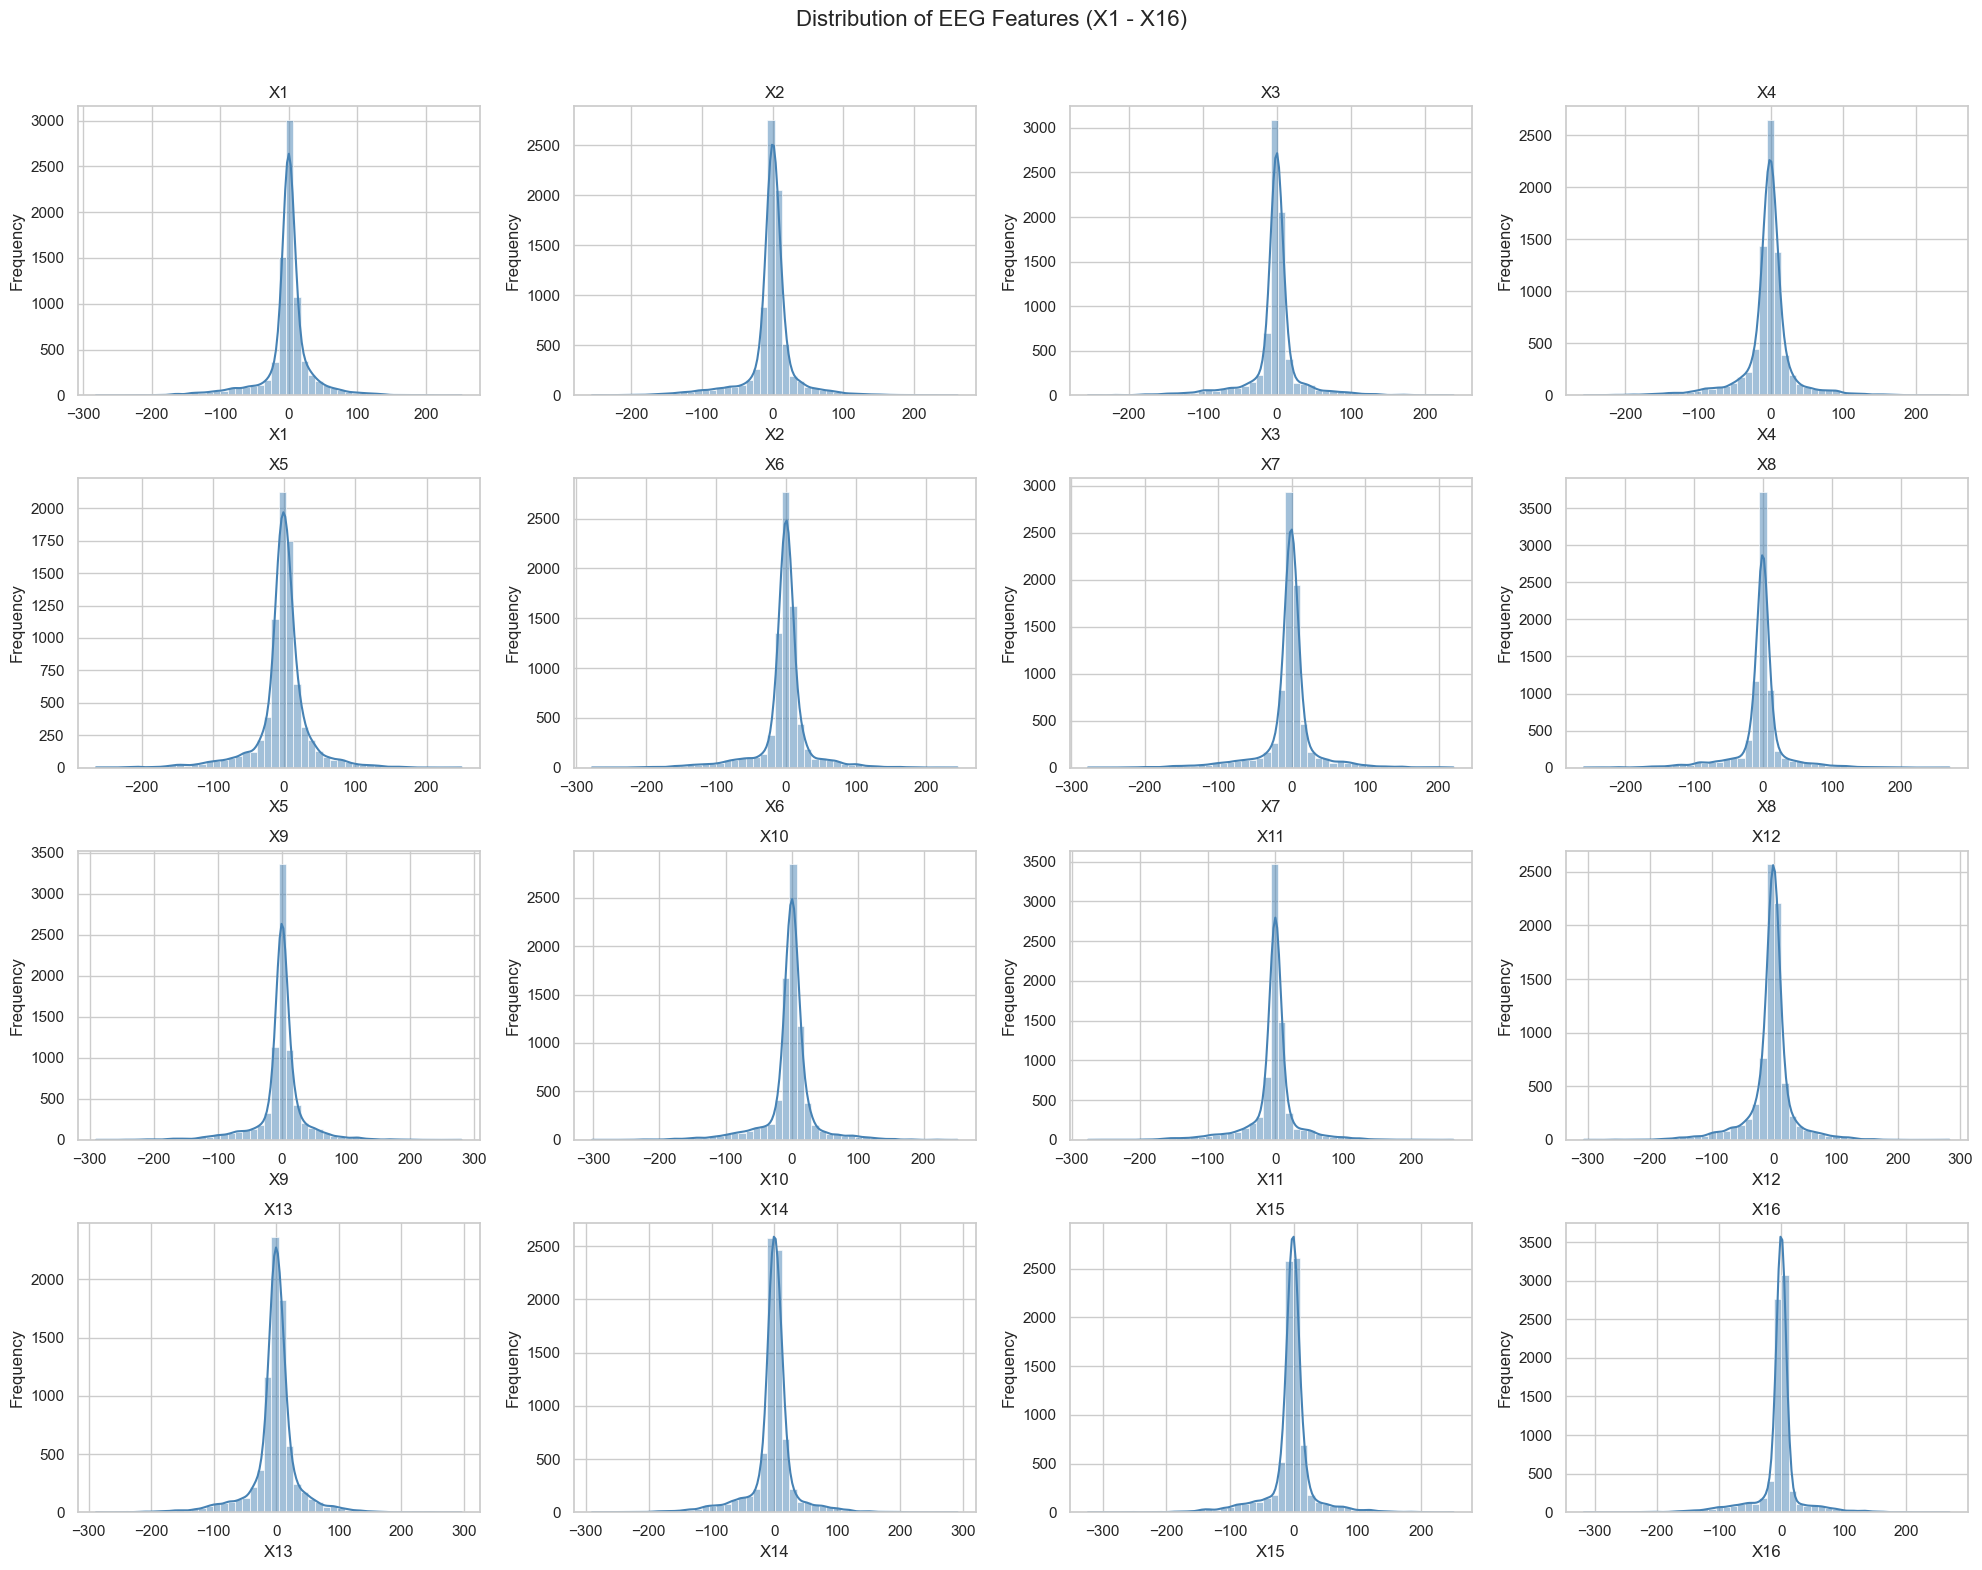

C:\Users\19012\AppData\Local\Temp\ipykernel_55688\1415768383.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='viridis')


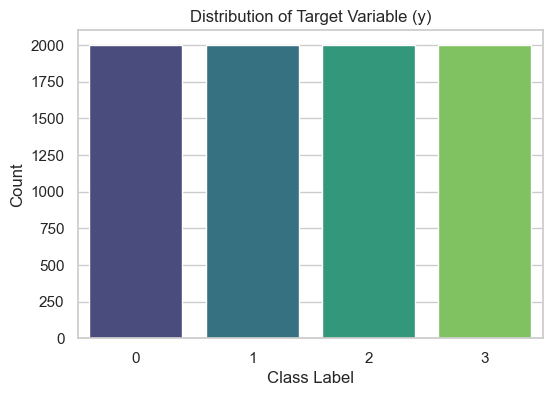

In [18]:
# Get feature columns
features = [col for col in df.columns if col.startswith('X')]

# Plot histograms for feature distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Distribution of EEG Features (X1 - X16)', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < len(features):
        sns.histplot(df[features[i]], bins=50, kde=True, ax=ax, color='steelblue')
        ax.set_title(features[i])
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Plot bar chart for target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

In [19]:
# Extract features X
X = df.drop(columns=['y'])

# ---------------------------------------------------------
# Task 1: Multi-class Classification
# ---------------------------------------------------------
y_multi = df['y']

# Split multi-class dataset (90% Train, 10% Validation), stratified by class
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X, y_multi, test_size=0.10, random_state=42, stratify=y_multi
)

# ---------------------------------------------------------
# Task 2: Binary Classification
# ---------------------------------------------------------
# Map binary labels: class 0 stays 0; classes 1/2/3 mapped to 1
y_bin = df['y'].apply(lambda val: 0 if val == 0 else 1)

# Split binary dataset (90% Train, 10% Validation)
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X, y_bin, test_size=0.10, random_state=42, stratify=y_bin
)

print(f"Multi-class - Train shape: {X_train_multi.shape}, Val shape: {X_val_multi.shape}")
print(f"Binary - Train shape: {X_train_bin.shape}, Val shape: {X_val_bin.shape}")

Multi-class - Train shape: (7200, 16), Val shape: (800, 16)
Binary - Train shape: (7200, 16), Val shape: (800, 16)


In [20]:
# Helper function: merge X and y, then save as CSV
def save_dataset(X, y, target_name, file_name):
    temp_df = X.copy()
    temp_df[target_name] = y
    save_path = os.path.join(processed_dir, file_name)
    temp_df.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

# Save multi-class data (keep target column name as 'y')
save_dataset(X_train_multi, y_train_multi, 'y', 'train_multi_raw.csv')
save_dataset(X_val_multi, y_val_multi, 'y', 'val_multi_raw.csv')

# Save binary data (target column as 'y' for consistent downstream loading)
save_dataset(X_train_bin, y_train_bin, 'y', 'train_bin_raw.csv')
save_dataset(X_val_bin, y_val_bin, 'y', 'val_bin_raw.csv')

print("\nAll raw-feature (16-dim) splits exported to ../Data/ successfully!")

Saved: ../Data\train_multi_raw.csv
Saved: ../Data\val_multi_raw.csv
Saved: ../Data\train_bin_raw.csv
Saved: ../Data\val_bin_raw.csv

All raw-feature (16-dim) splits exported to ../Data/ successfully!
